recompute scaling factor

In [1]:
import sys
import os

from pathlib import Path
sys.path.append(str(Path().resolve().parent))
str(Path().resolve().parent)

ROOT = Path(os.getcwd()).resolve().parent
ROOT

PosixPath('/Users/mohamedmafaz/Desktop/CFD_DiT')

In [2]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from VAE import VAE

import torch.nn.functional as F

In [3]:
from torch.utils.data import Dataset, DataLoader
from Data import dataset_cfd

In [43]:
import json
with open("../config/config.json", "r") as file:
    config = json.load(file)


stats = config['Stats']['Lid_Driven']

In [57]:
dataset    = dataset_cfd.dataset_csv(folder = f"{ROOT}/Data/Problems/Lid_Driven_domain", meta = "Lid_Driven", eps=0.001)
dataloader = DataLoader(dataset, batch_size = 1, shuffle=True, num_workers=2)

In [45]:
device = "cuda" if torch.cuda.is_available() else "cpu"

vae = VAE(device = device, freeze = True, scaling_factor = config["VAE"]["scaling_factor"], path = f"{ROOT}/pretrained/sd-vae-ft-mse")#, load_weights = f"{ROOT}/VAE.pth").to(device)
# use path = `stabilityai/sd-vae-ft-mse` for pulling weights from the internet
vae.eval()

VAE(
  (vae): AutoencoderKL(
    (encoder): Encoder(
      (conv_in): Conv2d(3, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (down_blocks): ModuleList(
        (0): DownEncoderBlock2D(
          (resnets): ModuleList(
            (0-1): 2 x ResnetBlock2D(
              (norm1): GroupNorm(32, 128, eps=1e-06, affine=True, bias=True)
              (conv1): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
              (norm2): GroupNorm(32, 128, eps=1e-06, affine=True, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
              (conv2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
              (nonlinearity): SiLU()
            )
          )
          (downsamplers): ModuleList(
            (0): Downsample2D(
              (conv): Conv2d(128, 128, kernel_size=(3, 3), stride=(2, 2))
            )
          )
        )
        (1): DownEncoderBlock2D(
          (resnets): ModuleList(
            (0): ResnetBlock

In [46]:
vae.load_state_dict(torch.load(f"{ROOT}/models/VAE.pth", map_location = device))

<All keys matched successfully>

In [62]:
# pick one actual training example
images, numbers, mask, _, _ = next(iter(dataloader))
true_number = numbers[0].item()      # already normalized, matches training distribution

In [63]:
(true_number * config["Stats"]["Lid_Driven"]['Re_Std'])+config["Stats"]["Lid_Driven"]['Re_Mean']

1441.2

In [64]:
def to_unit_range(x, lo, hi, **kwargs):   return 2.0 * (x - lo) / (hi - lo) - 1.0
def from_unit_range(y, lo, hi, **kwargs): return (((y + 1.0) / 2.0) * (hi - lo)) + lo


Normalized P:
min: -21.200586
max: 0.0


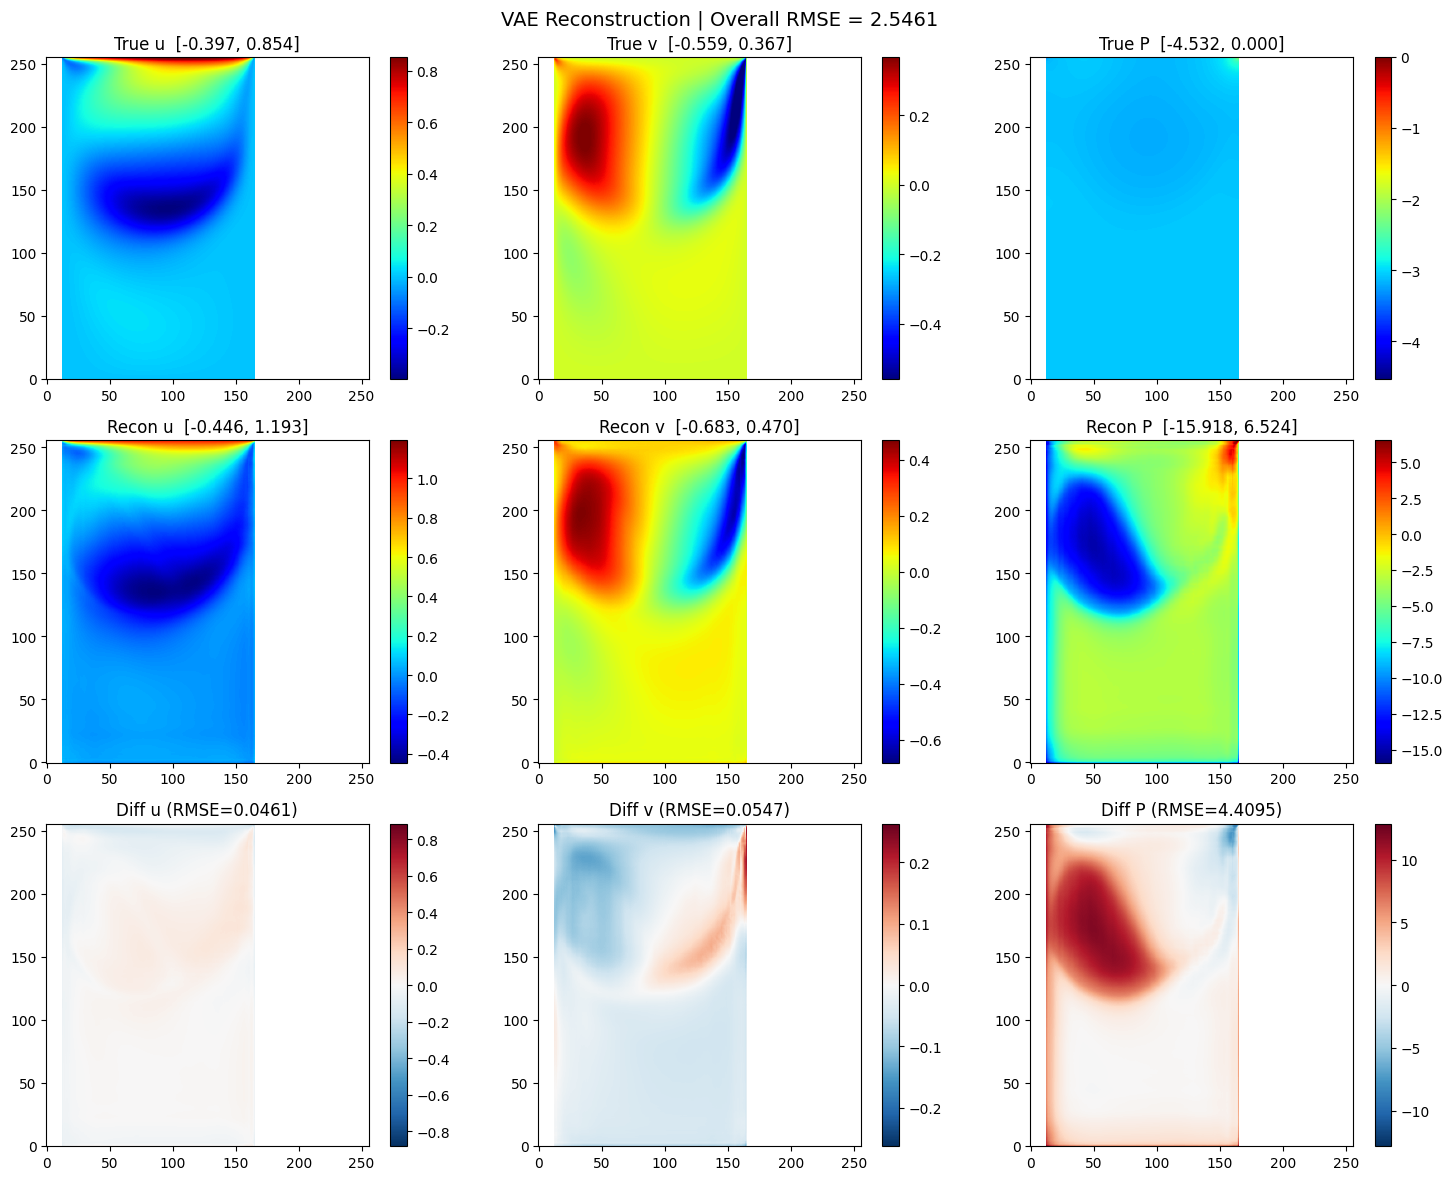

In [65]:
with torch.no_grad():
    mu, logvar = vae.encode(images.to(device))
    recon = vae.decode(mu)  

idx = 0
true_np  = images[idx].detach().cpu().numpy()   
recon_np = recon[idx].detach().cpu().numpy()   

true_np[0] = from_unit_range(true_np[0], stats['U_CLIP_MIN'], stats['U_CLIP_MAX'], eps = 0.001)
true_np[1] = from_unit_range(true_np[1], stats['V_CLIP_MIN'], stats['V_CLIP_MAX'], eps = 0.001)
true_np[2] = from_unit_range(true_np[2], stats['P_CLIP_MIN'], stats['P_CLIP_MAX'], eps = 0.001)

p_norm = images[idx, 2].detach().cpu().numpy()

print("\nNormalized P:")
print("min:", p_norm.min())
print("max:", p_norm.max())

recon_np[0] = from_unit_range(recon_np[0], stats['U_CLIP_MIN'], stats['U_CLIP_MAX'], eps = 0.001)
recon_np[1] = from_unit_range(recon_np[1], stats['V_CLIP_MIN'], stats['V_CLIP_MAX'], eps = 0.001)
recon_np[2] = from_unit_range(recon_np[2], stats['P_CLIP_MIN'], stats['P_CLIP_MAX'], eps = 0.001)

channel_names = ["u", "v", "P"]
m = mask[0].numpy().astype(bool)

fig, axes = plt.subplots(3, 3, figsize=(15, 12))

all_true = np.concatenate([true_np[i][m] for i in range(3)])
all_recon = np.concatenate([recon_np[i][m] for i in range(3)])
overall_rmse = np.sqrt(np.mean((all_true - all_recon) ** 2))

for i, name in enumerate(channel_names):
    true_ch  = true_np[i]
    recon_ch = recon_np[i]
    diff_ch  = true_ch - recon_ch

    rmse = np.sqrt(np.mean(diff_ch[m] ** 2))
    diff_abs_max = np.abs(diff_ch[m]).max()

    a = axes[0, i].imshow(np.where(m, true_ch, np.nan), cmap="jet", origin="lower")
    axes[0, i].set_title(f"True {name}  [{true_ch[m].min():.3f}, {true_ch[m].max():.3f}]")
    fig.colorbar(a, ax=axes[0, i])

    b = axes[1, i].imshow(np.where(m, recon_ch, np.nan), cmap="jet", origin="lower")
    axes[1, i].set_title(f"Recon {name}  [{recon_ch[m].min():.3f}, {recon_ch[m].max():.3f}]")
    fig.colorbar(b, ax=axes[1, i])

    c = axes[2, i].imshow(np.where(m, diff_ch, np.nan), cmap="RdBu_r",
                           vmin=-diff_abs_max, vmax=diff_abs_max, origin="lower")
    axes[2, i].set_title(f"Diff {name} (RMSE={rmse:.4f})")
    fig.colorbar(c, ax=axes[2, i])

fig.suptitle(f"VAE Reconstruction | Overall RMSE = {overall_rmse:.4f}", fontsize=14)

plt.tight_layout()
plt.show()